In [5]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [12]:
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [13]:
def Calculate_bmi(state:BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight / (height**2)

    state['bmi'] = round(bmi,2)

    return state

def Label_Bmi(state:BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = "Underweight"
    elif 18.5 <= bmi < 25:
        state['category'] = "Normal"
    elif 25 <= bmi < 30:
        state['category'] = "Overweight"
    else:
        state['category'] = "Obese" 

    return state

In [15]:
# Defining Graph
graph = StateGraph(BMIState)

# Nodes 
graph.add_node("Calculate_bmi",Calculate_bmi)
graph.add_node("Label_bmi",Label_Bmi)

# Edges
graph.add_edge(START,"Calculate_bmi")
graph.add_edge("Calculate_bmi","Label_bmi")
graph.add_edge("Label_bmi",END)

# Compile Graph
workflow = graph.compile()

In [20]:
initial_state = {"weight_kg":80 , "height_m":2.3}
final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 2.3, 'bmi': 15.12, 'category': 'Underweight'}


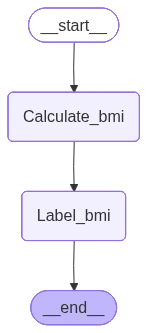

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())